# Occupied 점의 Multi-View Reprojection 오차 검증

가설: **실제 표면(occupied) 점이라도, pose 오차·픽셀 분해능 때문에 다른 프레임에 투영하면 외형이 어긋난다. 특히 엣지(이미지 gradient 큰 곳)에서 심하다.**

- occupied 점을 여러 color frame에 투영 → bilinear RGB 샘플
- **2-프레임 쌍 오차** + **multi-view RGB std**(일관성 오차) 측정
- 각 점의 **국소 이미지 gradient**와 오차의 상관 확인 (엣지 = 고오차 검증)
- 오차를 점군 색으로 시각화

occupied 점 소스: 컬러 occ grid PLY(있으면 occupied 색 필터) 또는 LiDAR depths(=occupied 표면) fallback.

의존성: numpy, PIL

In [1]:
import numpy as np, glob, os, re
from PIL import Image

ROOT = "/home/dev/jkpark/M2Mapping/data/iae_map"
OCC_PLY = ROOT + "/.occ_cache/as_prior.ply"   # occ grid(world좌표). 컬러 ply면 occupied 필터, xyz-only면 전체
OCC_COLOR_RGB = (220, 40, 40)   # occupied로 칠한 색 (C++ 컬러 export와 일치시킬 것)
MAX_PTS = 60000   # occ grid 점 많으니 subsample

fx, fy, cx, cy = 580.9368694958202, 580.8762078586867, 599.8374474091759, 327.7756256909918
W, H = 1280, 720

N_PLY     = 80     # OCC_PLY 없을 때만: LiDAR fallback용
PTS_PER   = 500
N_FRAMES  = 250    # 투영에 쓸 color 프레임 수
np.random.seed(0)

In [2]:
def numkey(p): return int(re.search(r"(\d+)", os.path.basename(p)).group(1))

def read_ply(path, want_rgb=False):
    """PCL/colored ply -> xyz [N,3] (+ rgb [N,3] if want_rgb)."""
    f = open(path, "rb"); h = b""
    while b"end_header" not in h: h += f.readline()
    t = h.decode("ascii", "ignore")
    n = int(re.search(r"element vertex (\d+)", t).group(1))
    props = re.findall(r"property\s+\S+\s+(\S+)", t)
    skip = t[:t.find("end_header")].count("\n") + 1
    cols = list(range(len(props)))
    arr = np.loadtxt(path, skiprows=skip, max_rows=n, usecols=cols).reshape(n, -1)
    xi, yi, zi = props.index("x"), props.index("y"), props.index("z")
    xyz = arr[:, [xi, yi, zi]].astype(np.float64)
    if want_rgb and "red" in props:
        ri, gi, bi = props.index("red"), props.index("green"), props.index("blue")
        return xyz, arr[:, [ri, gi, bi]].astype(np.int32)
    return xyz, None

def bilinear(img, u, v):
    Hh, Ww = img.shape[:2]
    x0 = np.floor(u).astype(int); y0 = np.floor(v).astype(int)
    x1, y1 = x0 + 1, y0 + 1
    valid = (u >= 0) & (u <= Ww - 1) & (v >= 0) & (v <= Hh - 1)
    x0c, x1c = np.clip(x0, 0, Ww - 1), np.clip(x1, 0, Ww - 1)
    y0c, y1c = np.clip(y0, 0, Hh - 1), np.clip(y1, 0, Hh - 1)
    wx = (u - x0)[:, None]; wy = (v - y0)[:, None]
    f = (img[y0c, x0c]*(1-wx)*(1-wy) + img[y0c, x1c]*wx*(1-wy) +
         img[y1c, x0c]*(1-wx)*wy + img[y1c, x1c]*wx*wy)
    f[~valid] = 0
    return f, valid

def turbo(x):
    x = np.clip(x, 0, 1)
    r = np.clip(1.5 - np.abs(4*x - 3), 0, 1); g = np.clip(1.5 - np.abs(4*x - 2), 0, 1)
    b = np.clip(1.5 - np.abs(4*x - 1), 0, 1)
    return np.stack([r, g, b], 1) * 255

def write_ply(path, xyz, rgb):
    rgb = np.clip(rgb, 0, 255).astype(np.uint8)
    with open(path, "w") as f:
        f.write(f"ply\nformat ascii 1.0\nelement vertex {len(xyz)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
        for p, c in zip(xyz, rgb):
            f.write(f"{p[0]:.4f} {p[1]:.4f} {p[2]:.4f} {c[0]} {c[1]} {c[2]}\n")
    print("wrote", path)

def render_topdown(xyz, rgb, RES=900, ps=1):
    x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
    s = min((RES-20)/(x.max()-x.min()), (RES-20)/(y.max()-y.min()))
    px = np.clip(((x-x.min())*s+10).astype(int), 0, RES-1)
    py = np.clip((RES-1-((y-y.min())*s+10)).astype(int), 0, RES-1)
    img = np.zeros((RES,RES,3), np.uint8); zb = np.full((RES,RES), -1e9)
    rgb = np.clip(rgb,0,255).astype(np.uint8)
    for i in np.argsort(z):
        a,b = py[i], px[i]
        for dy in range(-ps,ps+1):
            for dx in range(-ps,ps+1):
                yy,xx=a+dy,b+dx
                if 0<=yy<RES and 0<=xx<RES and z[i]>zb[yy,xx]:
                    img[yy,xx]=rgb[i]; zb[yy,xx]=z[i]
    return Image.fromarray(img)

In [3]:
# ===== occupied 점 로드 (occ grid = world좌표, 변환 불필요) =====
cp = np.loadtxt(f"{ROOT}/color_poses.txt").reshape(-1, 4, 4)
imgs = {numkey(p): p for p in glob.glob(f"{ROOT}/images/*.png")}
img_keys = sorted(imgs)

if OCC_PLY and os.path.exists(OCC_PLY):
    xyz, rgb = read_ply(OCC_PLY, want_rgb=True)
    if rgb is not None:
        m = np.all(np.abs(rgb - np.array(OCC_COLOR_RGB)) < 30, axis=1)  # occupied 색 필터
        X = xyz[m]
        print(f"occ grid ply: occupied 색 필터 {len(X)}/{len(xyz)}점")
    else:
        X = xyz                                                          # xyz-only ply
        print(f"occ grid ply(xyz-only): {len(X)}점 (occupied+visible-unknown 혼재)")
else:
    dp = np.loadtxt(f"{ROOT}/depth_poses.txt").reshape(-1, 4, 4)
    plys = sorted(glob.glob(f"{ROOT}/depths/*.ply"), key=numkey)
    pts = []
    for k in np.linspace(0, len(plys)-1, N_PLY).astype(int):
        pc, _ = read_ply(plys[k])
        if len(pc)==0: continue
        pc = pc[np.random.choice(len(pc), min(PTS_PER, len(pc)), replace=False)]
        T = dp[k]; pc = (T[:3,:3] @ pc.T).T + T[:3,3]
        pts.append(pc)
    X = np.concatenate(pts, 0)
    print(f"LiDAR depths fallback: occupied(표면) {len(X)}점")

if len(X) > MAX_PTS:
    X = X[np.random.choice(len(X), MAX_PTS, replace=False)]
    print(f"subsample -> {len(X)}점")

N = len(X); Xh = np.concatenate([X, np.ones((N,1))], 1)

occ grid ply(xyz-only): 428670점 (occupied+visible-unknown 혼재)
subsample -> 60000점


In [4]:
# ===== 모든 프레임에 투영: 각 점의 visible 프레임에서 RGB + 국소 gradient 수집 =====
fidx = np.linspace(0, min(len(cp), len(img_keys))-1, N_FRAMES).astype(int)
C = 3
sum_c = np.zeros((N, C)); sum_c2 = np.zeros((N, C)); cnt = np.zeros(N)
sum_grad = np.zeros(N)
# 2-프레임 쌍 오차용: 각 점의 '첫/마지막' visible 프레임 RGB 저장
first_c = np.full((N, C), np.nan); last_c = np.full((N, C), np.nan)

for j, i in enumerate(fidx):
    img = np.asarray(Image.open(imgs[img_keys[i]]).convert("RGB"), np.float32)/255.0
    gy, gx = np.gradient(img.mean(2))           # 국소 밝기 gradient
    gmag = np.sqrt(gx**2 + gy**2)               # [H,W]
    w2c = np.linalg.inv(cp[i])
    cam = (w2c @ Xh.T).T[:, :3]
    z = cam[:,2]; zs = np.where(np.abs(z)<1e-9, 1e-9, z)
    u = fx*cam[:,0]/zs + cx; v = fy*cam[:,1]/zs + cy
    feat, vin = bilinear(img, u, v)
    gsamp, _ = bilinear(gmag[:,:,None], u, v)
    m = (z>0) & vin
    sum_c[m]  += feat[m]; sum_c2[m] += feat[m]**2; cnt[m] += 1
    sum_grad[m] += gsamp[m,0]
    # 첫/마지막 visible 기록 (서로 다른 시점쌍)
    nf = m & np.isnan(first_c[:,0]); first_c[nf] = feat[nf]
    last_c[m] = feat[m]
    if (j+1)%50==0: print(f"  {j+1}/{N_FRAMES}")

  50/250
  100/250
  150/250
  200/250
  250/250


In [5]:
# ===== 오차 지표 =====
valid = cnt >= 2
denom = np.clip(cnt, 1, None)[:, None]
mean_c = sum_c/denom
var_c  = np.clip(sum_c2/denom - mean_c**2, 0, None)
mv_std = np.sqrt(var_c.mean(1))                          # multi-view RGB std (전체 일관성 오차)
pair_err = np.linalg.norm(first_c - last_c, axis=1)      # 2-프레임 쌍 오차
avg_grad = sum_grad/np.clip(cnt,1,None)                  # 평균 국소 gradient (엣지성)

v = valid & np.isfinite(pair_err)
print("================ REPROJECTION ERROR (occupied) ================")
print(f"valid(>=2 view) 점수: {v.sum()} / {N}")
print(f"multi-view RGB std : median {np.median(mv_std[v]):.3f}  90%ile {np.percentile(mv_std[v],90):.3f}  max {mv_std[v].max():.3f}")
print(f"2-frame pair err   : median {np.median(pair_err[v]):.3f}  90%ile {np.percentile(pair_err[v],90):.3f}")
# 엣지(고 gradient) vs 비엣지 오차 비교 — 가설 검증
g_hi = avg_grad > np.percentile(avg_grad[v], 75)
g_lo = avg_grad < np.percentile(avg_grad[v], 25)
print(f"\n[가설] 엣지(고 gradient)에서 오차가 큰가?")
print(f"  고-gradient 점 mv_std median: {np.median(mv_std[v & g_hi]):.3f}")
print(f"  저-gradient 점 mv_std median: {np.median(mv_std[v & g_lo]):.3f}")
corr = np.corrcoef(avg_grad[v], mv_std[v])[0,1]
print(f"  corr(gradient, mv_std) = {corr:.3f}   (양수 클수록 '엣지=고오차' 가설 지지)")
print("==============================================================")

================ REPROJECTION ERROR (occupied) ================
valid(>=2 view) 점수: 60000 / 60000
multi-view RGB std : median 0.254  90%ile 0.325  max 0.429
2-frame pair err   : median 0.461  90%ile 1.098

[가설] 엣지(고 gradient)에서 오차가 큰가?
  고-gradient 점 mv_std median: 0.292
  저-gradient 점 mv_std median: 0.221
  corr(gradient, mv_std) = 0.421   (양수 클수록 '엣지=고오차' 가설 지지)


## 시각화: 오차를 점군 색으로 (빨강=고오차)

wrote /home/dev/jkpark/M2Mapping/notebooks/occ_reproj_mvstd.ply


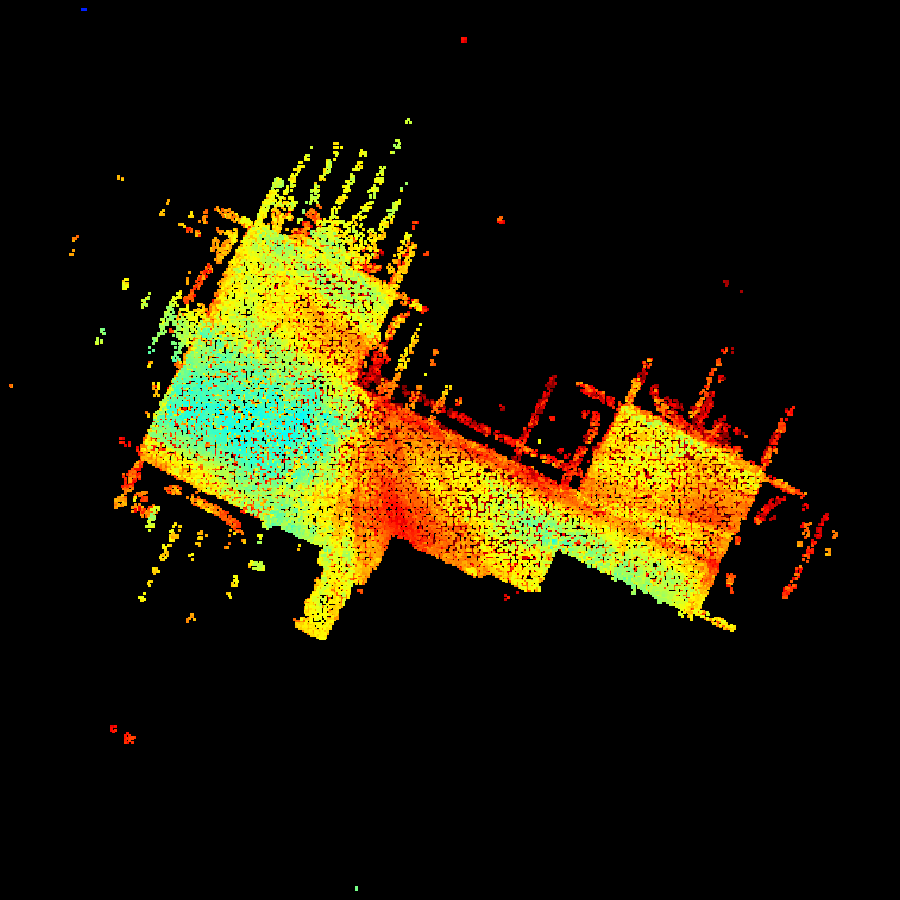

In [6]:
# (1) multi-view RGB std 히트맵
Xv = X[v]
e = mv_std[v] / (np.percentile(mv_std[v], 95) + 1e-9)
write_ply("/home/dev/jkpark/M2Mapping/notebooks/occ_reproj_mvstd.ply", Xv, turbo(e))
render_topdown(Xv, turbo(e))

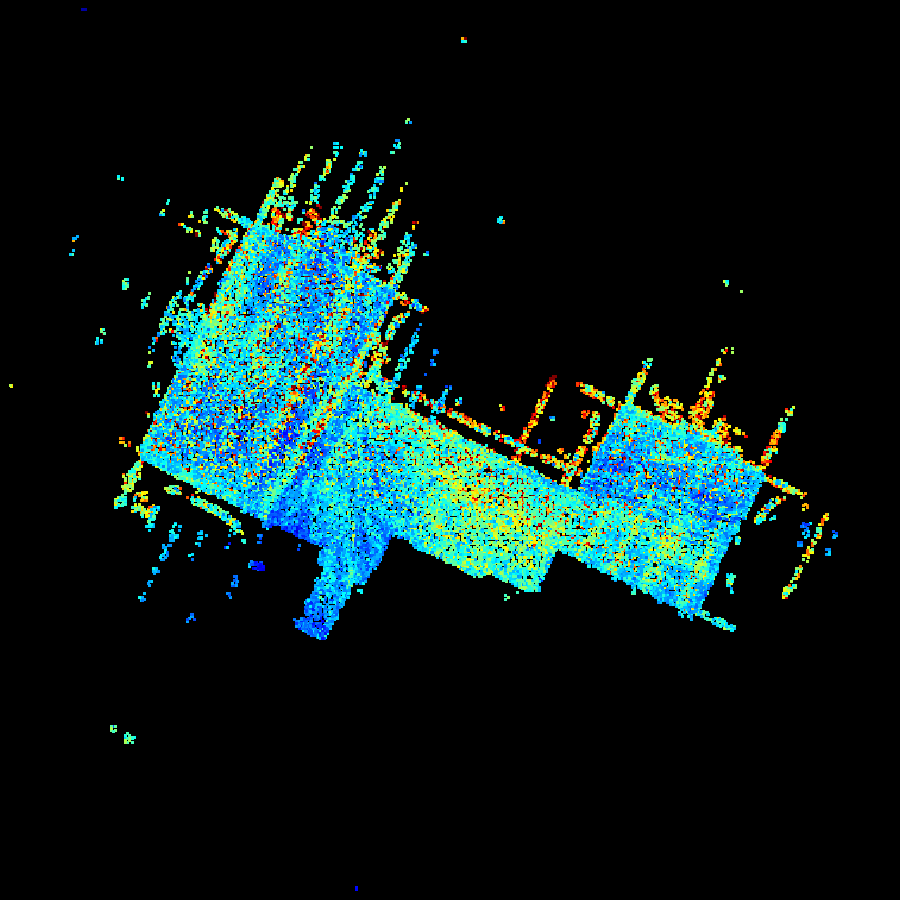

In [7]:
# (2) 국소 gradient(엣지성) 히트맵 — 위 오차맵과 패턴 비교
g = avg_grad[v] / (np.percentile(avg_grad[v], 95) + 1e-9)
render_topdown(Xv, turbo(g))